## Chapter 2: Combinatorial Classes

This is the Sage notebook for [**Chapter 2 of enumeration.ca**](https://enumeration.ca/basics/classes/) by Stephen Melczer. We discuss some of the many combinatorial objects that one can play around with in Sage, returning to many of them later in the notes.

More details on Sage can be found in the [**official documentation**](https://doc.sagemath.org/html/en/reference/index.html) (including the [**combinatorics tutorial**](https://doc.sagemath.org/html/en/reference/combinat/sage/combinat/tutorial.html#sage-combinat-tutorial) from which some of the basic examples here are taken) or the textbook [**Computational Mathematics with SageMath**](http://sagebook.gforge.inria.fr/english.html).

In [1]:
%display default

### Strings

In [2]:
# We can define the class of binary words
W = FiniteWords([0,1])

In [3]:
# We can list all words of a given length (but this is kind of boring)
list(W.iterate_by_length(4))

[word: 0000,
 word: 0001,
 word: 0010,
 word: 0011,
 word: 0100,
 word: 0101,
 word: 0110,
 word: 0111,
 word: 1000,
 word: 1001,
 word: 1010,
 word: 1011,
 word: 1100,
 word: 1101,
 word: 1110,
 word: 1111]

In [4]:
# We can test for patterns using string recognition -- here we look at words avoiding '11'
[s for s in W.iterate_by_length(4) if not '11' in str(s)]

[word: 0000,
 word: 0001,
 word: 0010,
 word: 0100,
 word: 0101,
 word: 1000,
 word: 1001,
 word: 1010]

In [5]:
# Does the counting sequence look familiar?
[len([s for s in W.iterate_by_length(k) if not '11' in str(s)]) for k in range(10)]

[1, 2, 3, 5, 8, 13, 21, 34, 55, 89]

The following example is a (very simplified version of) a bioinformatics problem related to genetic disorders like Huntington's Disease. In real-life, the HTT gene related to Huntington's Disease has around 170,000 base pairs and the bases that appear in sequence are not independent. Bioinformatics develops many specialized tools to work at the scale and level of generality needed to study such problems. See the Wikipedia page for [Huntington's Disease](https://en.wikipedia.org/wiki/Huntington%27s_disease#Genetic_mutation) or [Trinucleotide repeat disorders](https://en.wikipedia.org/wiki/Trinucleotide_repeat_disorder#Types) for more information.

In [6]:
# Count the number of ACGT strings of length 10 that contain the pattern 'CAGCAG'
len([s for s in FiniteWords(['A','C','G','T']).iterate_by_length(10) if 'CAGCAG' in str(s)])

1272

In [7]:
# We can even study infinite binary words!
W = InfiniteWords([0,1])
W

Infinite words over {0, 1}

In [8]:
# We can generate random words (but this is kind of boring)
W.random_element()

word: 1111111111001000110001001111101110100100...

In [9]:
# We can also build infinite words using a construction function
# Here we build the binary word w where w_n = 0 if n has an even number of 1s in binary and 0 otherwise
w = W(lambda n : add(NN(n).digits(2)) % 2)
w

word: 0110100110010110100101100110100110010110...

In [10]:
# We can then study properties of the sequence
pref = w.palindrome_prefixes_iterator()
for _ in range(5):
    print(next(pref))


0
0110
0110100110010110
0110100110010110100101100110100110010110011010010110100110010110


In [11]:
# Famous words (such as this one) are hardcoded into Sage
# See https://en.wikipedia.org/wiki/Thue%E2%80%93Morse_sequence for more on this sequence including connections to game theory, fractals, the Riemann zeta function, and more
words.ThueMorseWord()

word: 0110100110010110100101100110100110010110...

### Subsets and Permutations

In [12]:
# The cartesian_product procedure can be used to create a set of pairs
# Here we create a deck of cards and draw a random element
Suits = Set(["Clubs", "Spades", "Hearts", "Diamonds"])
Values = Set([2, 3, 4, 5, 6, 7, 8, 9, 10, "Jack", "Queen", "King", "Ace"])
Cards = cartesian_product([Values, Suits])
Cards.random_element()

('King', 'Hearts')

In [13]:
# This represents all 5 card hands
Subsets(Cards, 5)

Subsets of The Cartesian product of ({2, 3, 4, 5, 6, 7, 8, 9, 10, 'Jack', 'Queen', 'King', 'Ace'}, {'Clubs', 'Diamonds', 'Hearts', 'Spades'}) of size 5

In [14]:
# Draw a random hand of 5 cards
Subsets(Cards, 5).random_element()

{('Queen', 'Spades'), ('King', 'Clubs'), (9, 'Diamonds'), (2, 'Hearts'), (3, 'Hearts')}

In [15]:
# Count the number of hands
len(Subsets(Cards, 5))

2598960

In [16]:
# As expected this equals 52 choose 5
binomial(52,5)

2598960

In [17]:
# A permutation can be entered as a list of numbers
s = Permutation([5,1,7,4,6,3,2])
s

[5, 1, 7, 4, 6, 3, 2]

In [18]:
# We can compute various information about the permutation
s.fixed_points()

[4]

In [19]:
# Permutations can also be entered in cycle notation
p = Permutation('(1,2)(3,4,5)')
p

[2, 1, 4, 5, 3]

In [20]:
p.longest_increasing_subsequences()

[[2, 4, 5], [1, 4, 5]]

In [21]:
# Here is the binary search tree we obtain from this permutation
ascii_art(p.binary_search_tree())

  _2_
 /   \
1     4
     / \
    3   5

In [22]:
# Some types of Permutations have their own classes or constructors
# A derangement is a permutation p where p_k does not equal k for all k
list(Derangements(3))

[[2, 3, 1], [3, 1, 2]]

In [23]:
# We can count derangements
[len(Derangements(k)) for k in range(10)]

[1, 0, 1, 2, 9, 44, 265, 1854, 14833, 133496]

In [24]:
# We will see how to compute their (exponential) generating function later 
EGF = exp(-x)/(1-x)
[EGF.series(x,10).coefficient(x,k) * factorial(k) for k in range(10)]

[1, 0, 1, 2, 9, 44, 265, 1854, 14833, 133496]

### Lattice Paths

In [25]:
# A Dyck path is a sequence of (1,1) and (1,-1) steps that starts at (0,0) and ends on the x-axis that never goes below the x-axis
# A convenient way to work with Dyck paths in Sage is through Dyck words
DW = list(DyckWords(5))
w = DW[20]
w

In [26]:
# The 'word' is a string on ( and ) such that there are never more ) than ( and the total number of ( and ) is the same
print(w)

(()())(())


In [27]:
ascii_art(w)

 /\/\  /\ 
/    \/  \

In [28]:
# We can compute information about the paths
w.returns_to_zero()

[6, 10]

In [29]:
# We can uniquely decompose Dyck paths by the first time they return to the x-axis (this will be useful when building its generating function)
ascii_art(w.first_return_decomposition())

(        /\  )
( /\/\, /  \ )

### Integer Compositions and Partitions

An **integer composition** of size $n$ is a tuple $(a_1,\dots,a_r)$ of positive integers such that $a_1 + \cdots + a_r = n$.

In [30]:
C5 = Compositions(5)
list(C5)

[[1, 1, 1, 1, 1],
 [1, 1, 1, 2],
 [1, 1, 2, 1],
 [1, 1, 3],
 [1, 2, 1, 1],
 [1, 2, 2],
 [1, 3, 1],
 [1, 4],
 [2, 1, 1, 1],
 [2, 1, 2],
 [2, 2, 1],
 [2, 3],
 [3, 1, 1],
 [3, 2],
 [4, 1],
 [5]]

In [31]:
# There are 2^(n-1) compositions of size n (for n >= 1)
[Compositions(k).cardinality() for k in range(10)]

[1, 1, 2, 4, 8, 16, 32, 64, 128, 256]

In [32]:
# We can generate random compositions. This can be useful for studying statistics.
Compositions(10).random_element()

[1, 3, 2, 1, 1, 1, 1]

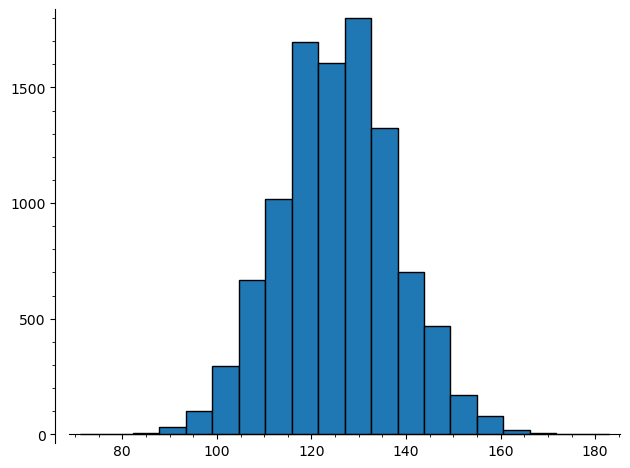

In [33]:
# We can count the number of times 1 appears in 10,000 random compositions of size 500
# Heuristically, it appears that the number of 1s satisfies a central limit theorem
histogram([Compositions(500).random_element().count(1) for _ in range(10000)], bins=20)

An **integer partition** of size $n$ is a tuple $(a_1,\dots,a_r)$ of positive integers in *weakly increasing order* $a_1 \leq \cdots \leq a_r$ such that $a_1 + \cdots + a_r = n$.

In [34]:
# List all partitions of size 5
P5 = Partitions(5)
list(P5)

[[5], [4, 1], [3, 2], [3, 1, 1], [2, 2, 1], [2, 1, 1, 1], [1, 1, 1, 1, 1]]

In [35]:
# Unlike compositions, there is no "nice" closed form for the number of partitions of size n
# The sequence still grows quickly
print(Partitions(100).cardinality())
print(Partitions(1000).cardinality())

190569292
24061467864032622473692149727991


In [36]:
# Commands like .cardinality() are optimized and much faster than generating all terms and then counting
print(timeit('Partitions(40).cardinality()'))
print(timeit('len(list(Partitions(40)))'))

625 loops, best of 3: 726 ns per loop
5 loops, best of 3: 65.2 ms per loop


In [37]:
# We can sample random elements
s = Partitions(30).random_element()
s

[13, 4, 4, 3, 3, 1, 1, 1]

In [38]:
# We can print the partition in a "Ferrers diagram"
ascii_art(s.ferrers_diagram())

*************
****
****
***
***
*
*
*

In [39]:
# We can default to printing with diagrams
%display ascii_art
list(Partitions(5))

[                                * ]
[                            **  * ]
[                   ***  **  *   * ]
[        ****  ***  *    **  *   * ]
[ *****, *   , ** , *  , * , * , * ]

In [40]:
# Reset display
%display default
list(Partitions(5))

[[5], [4, 1], [3, 2], [3, 1, 1], [2, 2, 1], [2, 1, 1, 1], [1, 1, 1, 1, 1]]

Euler derived the generating function
$$ P(z) = \prod_{k \geq 1}\frac{1}{1-z^k} $$
for integer partitions in 1748. We can verify this computationally for the first 10 terms.

In [41]:
# We expand 1/((1-z)(1-z^2)...(1-z^9) + O(z^10)) as a formal power series 
A.<z> = QQ[['z']] 
denom = prod([1-z^k for k in range(1,10)]) + O(z^10) 
1/denom

1 + z + 2*z^2 + 3*z^3 + 5*z^4 + 7*z^5 + 11*z^6 + 15*z^7 + 22*z^8 + 30*z^9 + O(z^10)

In [42]:
[Partitions(k).cardinality() for k in range(10)]

[1, 1, 2, 3, 5, 7, 11, 15, 22, 30]

In [43]:
aa = Partitions(10).random_element()

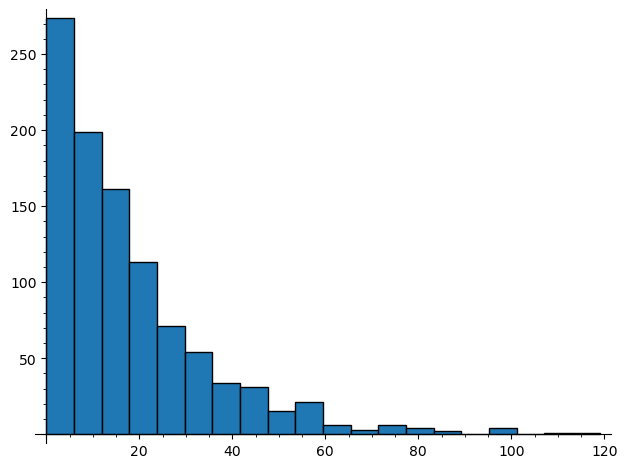

In [44]:
# If we count the number of 1s in random partitions we can see very different behaviour from compositions
histogram([list(Partitions(500).random_element()).count(1) for _ in range(1000)], bins=20)

### Trees and Graphs

In [45]:
# Sage has a special class for binary trees
B5 = BinaryTrees(3)
B5.cardinality()

5

In [46]:
list(B5)

[[., [., [., .]]],
 [., [[., .], .]],
 [[., .], [., .]],
 [[., [., .]], .],
 [[[., .], .], .]]

In [47]:
ascii_art(list(B5))

[ o    , o  ,   o  ,   o,     o ]
[  \      \    / \    /      /  ]
[   o      o  o   o  o      o   ]
[    \    /           \    /    ]
[     o  o             o  o     ]

In [48]:
# We can compute information about the trees
B5[0].depth()

3

In [49]:
# General rooted trees can also be defined in various ways
ascii_art(RootedTree([[[]], [[]], [[], []]]))

  __o___
 / /   / 
o o   o_
| |  / /
o o o o

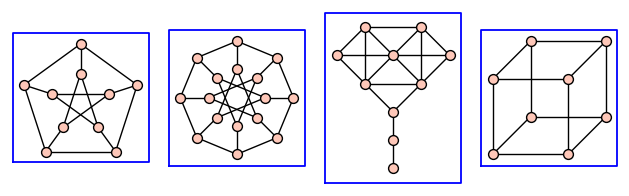

In [50]:
# You can build a general graph by defining vertices and edges, but some famous graphs are also built in
show(graphs.PetersenGraph(),graphs.MoebiusKantorGraph(),graphs.KrackhardtKiteGraph(),graphs.HexahedralGraph())

In [51]:
# Once a graph is defined, you can test various properties
G = graphs.PetersenGraph()
G.is_hamiltonian()

False

In [52]:
G.is_eulerian()

False

In [53]:
G.is_planar()

False

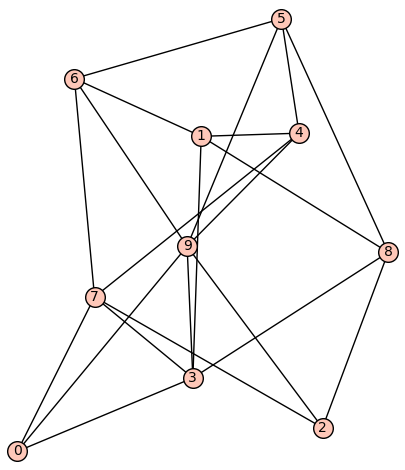

In [54]:
# Now we plot a random graph with 10 vertices where every pair of vertices is
# connected by an edge (or not) with probability 1/2
g = graphs.RandomGNP(10,1/2)
g.plot()

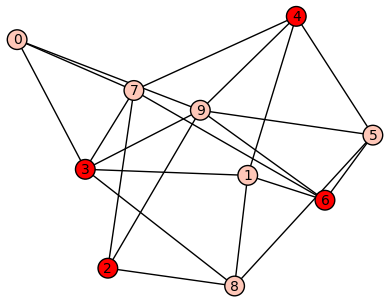

In [55]:
# Additional information can be added visually to plots
# Here we colour a maximum independent set
g.show(partition = [g.independent_set()])

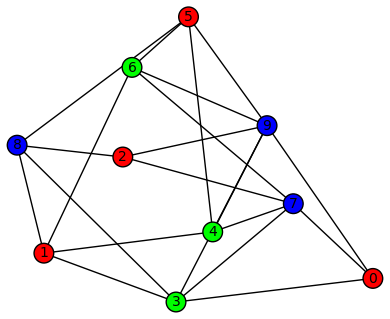

In [56]:
# Now we plot a proper vertex colouring with minimal number of colours
g.show(vertex_colors = g.coloring(hex_colors = True))

In [57]:
# You can also build graphs with specific properties -- here we count all planar graphs up to size 7
[len(list(graphs(n, property=lambda G: G.is_planar()))) for n in range(8)]

[1, 1, 2, 4, 11, 33, 142, 822]

### More Advanced Objects

Here are more combinatorial objects that can be studied in Sage. We will only see a few of these later in our course.

In [58]:
# A set partition of n in a decomposition of {1,2,...,n} into disjoint subsets
list(SetPartitions(3))

[{{1, 2, 3}}, {{1, 2}, {3}}, {{1, 3}, {2}}, {{1}, {2, 3}}, {{1}, {2}, {3}}]

In [59]:
sp = SetPartitions(20).random_element()
sp

{{1, 2, 4}, {3}, {5, 6, 9, 14}, {7, 10}, {8, 17, 20}, {11, 16}, {12}, {13, 18}, {15}, {19}}

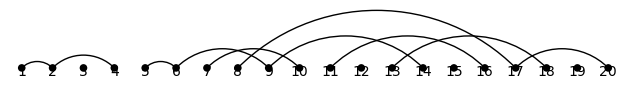

In [60]:
# We can plot a set partition by drawing n points on a line and connecting those in the same subset
sp.plot()

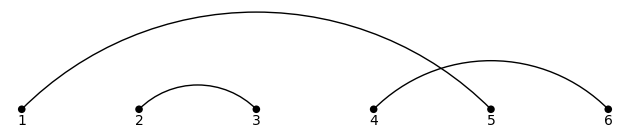

In [61]:
# The combinatorial class of (perfect) matchings consists of set partitions where each subset has size 2 
m = PerfectMatching([(1,5),(2,3),(4,6)])
m.plot()

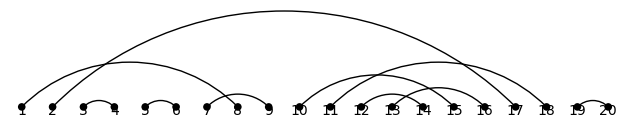

In [62]:
m = PerfectMatchings(20).random_element()
m.plot()

In [63]:
# We often want to study properties of a matching -- for instance which edges cross
m.crossings()

[((1, 8), (2, 17)),
 ((1, 8), (7, 9)),
 ((2, 17), (11, 18)),
 ((10, 15), (11, 18)),
 ((10, 15), (13, 16)),
 ((12, 14), (13, 16))]

In [64]:
# A poset is a partially ordered set -- see https://en.wikipedia.org/wiki/Partially_ordered_set
len(Posets(7))

2045

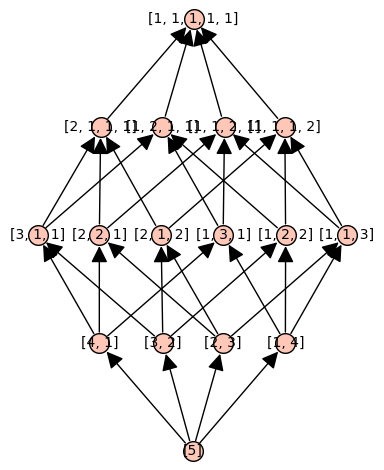

In [65]:
# Often times posets are constructed from other mathematical objects
IP = posets.IntegerCompositions(5)
IP.plot()

In [66]:
IP.antichains().random_element()

[[2, 1, 1, 1], [1, 1, 2, 1], [1, 1, 1, 2]]

In [67]:
len(list(IP.antichains()))

168

In [68]:
# An Alternating Sign Matrix is a matrix with entries in {0,1,-1} whose rows and columns sum to 1 and whose signs alternate along rows and columns
# See https://en.wikipedia.org/wiki/Alternating_sign_matrix for more info
# Proving a nice formula counting these was an open problem from ~1982 to ~1996
list(AlternatingSignMatrices(3))

[
[1 0 0]  [0 1 0]  [1 0 0]  [ 0  1  0]  [0 0 1]  [0 1 0]  [0 0 1]
[0 1 0]  [1 0 0]  [0 0 1]  [ 1 -1  1]  [1 0 0]  [0 0 1]  [0 1 0]
[0 0 1], [0 0 1], [0 1 0], [ 0  1  0], [0 1 0], [1 0 0], [1 0 0]
]

In [69]:
# Much attention is given to these objects because of connections to physics (and there is a nice proof of their counting formula using this connection)
# See https://en.wikipedia.org/wiki/Ice-type_model for more info
a = AlternatingSignMatrices(4).random_element()
print(a.to_six_vertex_model())

    ^    ^    ^    ^  
    |    |    |    |  
--> # -> # <- # <- # <--
    ^    |    ^    ^  
    |    V    |    |  
--> # <- # <- # <- # <--
    |    |    ^    ^  
    V    V    |    |  
--> # -> # -> # <- # <--
    |    |    |    ^  
    V    V    V    |  
--> # -> # -> # -> # <--
    |    |    |    |  
    V    V    V    V  


In [70]:
# There is support for matroids, including some famous matroids built in
F = matroids.named_matroids.Fano()
F

Fano: Binary matroid of rank 3 on 7 elements, type (3, 0)

In [71]:
F.automorphism_group().cardinality()

168

In [72]:
# There are robust features for working with symmetric functions in various bases
s = SymmetricFunctions(QQ).s()
s[2,1] * s[2,1]

s[2, 2, 1, 1] + s[2, 2, 2] + s[3, 1, 1, 1] + 2*s[3, 2, 1] + s[3, 3] + s[4, 1, 1] + s[4, 2]

In [73]:
ascii_art(s[2,1] * s[2,1])

s   + s   + s    + 2*s    + s    + s     + s    
 **    **    ***      ***    ***    ****    ****
 **    **    *        **     ***    *       **  
 *     **    *        *             *           
 *           *                                  

In [74]:
# There are many capabilities for computing with rational polytopes
A = random_matrix(ZZ, 4, 3, x=10)
L = LatticePolytope(A.rows())
L.points()

M(6, 3, 4),
M(9, 0, 1),
M(6, 1, 3),
M(6, 0, 1),
M(6, 1, 2),
M(6, 2, 3),
M(7, 0, 1),
M(7, 1, 2),
M(7, 2, 3),
M(8, 0, 1),
M(8, 1, 2)
in 3-d lattice M

In [75]:
L.plot3d()

Graphics3d Object

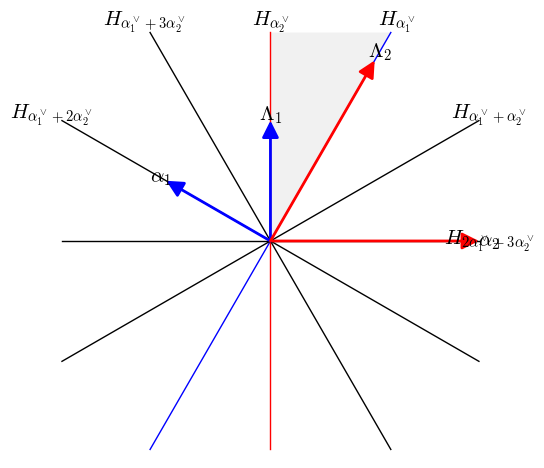

In [76]:
# Root systems appear often in algebraic combinatorics and representation theory
L = RootSystem(["G",2]).ambient_space()
L.plot(reflection_hyperplanes='all')

In [77]:
# A parking function of length n is a sequence s of natural numbers between 1 and n such that for each i the sequence contains at least i values that are at most i
# We can imagine n cars wanting to park in a lot with n spots -- car i prefers to park in spot s_i and if someone already has that spot they will park in the next free spot
# The conditions imply that every car will get a spot. A "lucky" car is a car that gets its preferred spot.
p = ParkingFunction([1,2,3,7,3,2,1,2,3,2,1])
p.lucky_cars()

[1, 2, 3, 4]

In [78]:
# Parking functions can be viewed as certain labelled Dyck paths -- see https://www.findstat.org/CollectionsDatabase/ParkingFunctions/ for more information 
p.pretty_print()

             _________
     _______| x x x x   4
    | x x x x x x x  .  9
    | x x x x x x  . .  5
   _| x x x x x  . . .  3
  | x x x x x  . . . . 10
  | x x x x  . . . . .  8
  | x x x  . . . . . .  6
 _| x x  . . . . . . .  2
| x x  . . . . . . . . 11
| x  . . . . . . . . .  7
|  . . . . . . . . . .  1



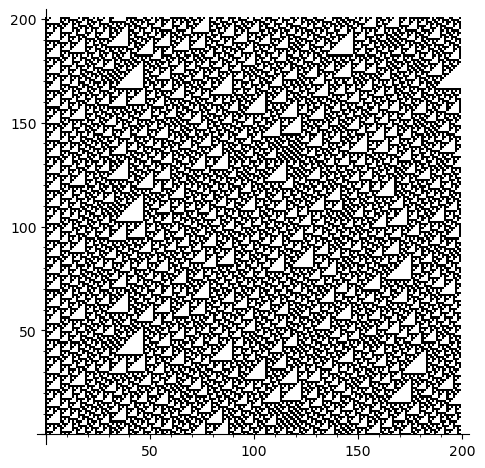

In [79]:
# We can compute the evolution of many different types of cellular automata
# Here is the evolution of a 1D automaton with the evolution plotted over time
ECA = cellular_automata.Elementary(60, width=200)
ECA.evolve(200)
plot(ECA)